In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=1000, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

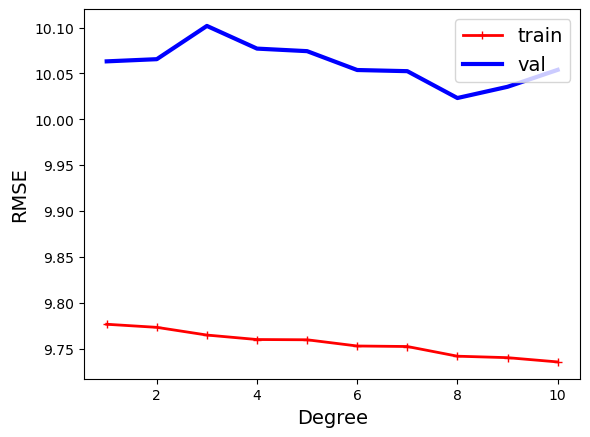

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# choose the best degree for the polynomial features
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_errors = []
val_errors = []

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_val_poly = poly_features.transform(X_val)
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_poly, y_train)
    y_train_predict = lin_reg.predict(X_train_poly)
    y_val_predict = lin_reg.predict(X_val_poly)
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

plt.plot(degrees, np.sqrt(train_errors), "r-+", linewidth=2, label="train")
plt.plot(degrees, np.sqrt(val_errors), "b-", linewidth=3, label="val")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Degree", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.show()

In [6]:
# evaluate the model on the test set
best_degree = np.argmin(val_errors) + 1
poly_features = PolynomialFeatures(degree=best_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)
y_test_predict = lin_reg.predict(X_test_poly)
test_error = mean_squared_error(y_test, y_test_predict)
# print dgree and rmse
print(best_degree, np.sqrt(test_error))

8 15.476051492878845
